<a href="https://colab.research.google.com/github/isAmirKhashimov/scikit-learn-labs/blob/stud%2Fkhashimov%2Flab2/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!wget -O lab2-10.xlsx "https://raw.githubusercontent.com/isAmirKhashimov/scikit-learn-labs/stud/khashimov/lab2/tasks/lab2/dataset/lab2-10.xlsx"

--2026-09-23 20:49:37--  https://raw.githubusercontent.com/isAmirKhashimov/scikit-learn-labs/stud/khashimov/lab2/tasks/lab2/dataset/lab2-10.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34607 (34K) [application/octet-stream]
Saving to: ‘lab2-10.xlsx’

lab2-10.xlsx        100%[===================>]  33.80K  --.-KB/s    in 0.003s  

2026-09-23 20:49:37 (9.62 MB/s) - ‘lab2-10.xlsx’ saved [34607/34607]



In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [7]:
df = pd.read_excel("lab2-10.xlsx")
df.columns = ["first", "second"]
x = df[["first", "second"]]

df.head()

,first,second
0,-5.401133,8.837667
1,-10.913359,8.084845
2,4.376475,7.348638
3,3.106731,-6.352393
4,4.906536,1.789281


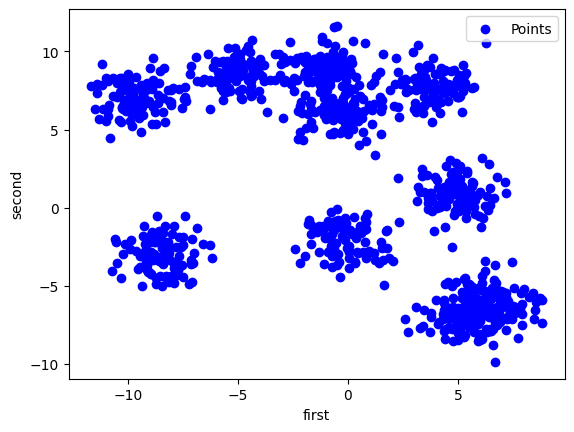

In [21]:
plt.scatter(df['first'], df['second'], color='blue', marker='o', label='Points')

plt.xlabel('first')
plt.ylabel('second')
plt.legend()
plt.Normalize()

plt.show()

<Axes: title={'center': 'Dataset visualization'}, xlabel='first', ylabel='second'>

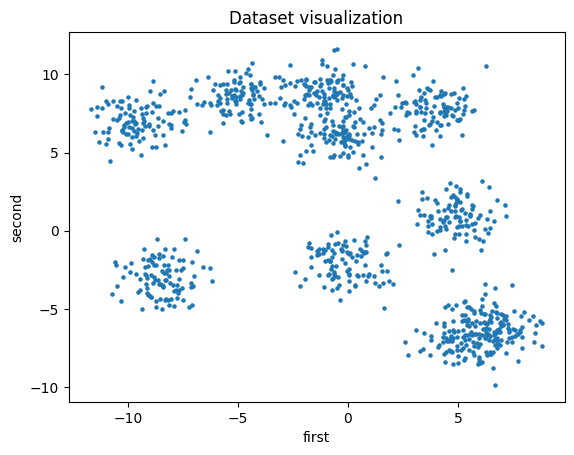

In [28]:
df.plot(kind='scatter', x='first', y='second', marker='.', title='Dataset visualization')

### Определим число кластеров
Визуально видим 4 явные группы и 4 группы переплетенные тесно между собой

### Выбор модели
В качестве метода кластеризации я остановился на следующих трех:
- K-Means;
- Spectral clustering;
- Gaussian mixtures.

In [78]:
CLUSTERS_COUNT = 8
KMEANS              = 'k-means'
SPECTRAL_CLUSTERING = 'spectral clustering'
GAUSSIAN_MIXTURES   = 'gaussian mixtures'

In [76]:
def get_model(method, clusters_count):
  if method == 'k-means':
    model = KMeans(
      n_clusters=clusters_count,
      random_state=9241
    )
  elif method == 'spectral clustering':
    model = SpectralClustering(
      n_clusters=clusters_count,
      random_state=9242
    )
  elif method == 'gaussian mixtures':
    model = GaussianMixture(
      n_components=clusters_count,
      random_state=9244
    )
  else:
    raise ValueError(f'Unknown clustering method: {method}')

  model.label = method
  return model

In [79]:
model1 = get_model(KMEANS, CLUSTERS_COUNT)
model2 = get_model(SPECTRAL_CLUSTERING, CLUSTERS_COUNT)
model3 = get_model(GAUSSIAN_MIXTURES, CLUSTERS_COUNT)

In [61]:
x_train, x_test = train_test_split(x, test_size=0.4, random_state=9245)

In [80]:
def train_model(model):
  model.fit(x_train)
  train_labels = model.predict(x_train)
  test_labels = model.predict(x_test)

  return train_labels, test_labels

In [81]:
train_labels1, test_labels1 = train_model(model1)
train_labels3, test_labels3 = train_model(model3)

# Метод у SpectralClustering отличается, вызываю отдельно
train_labels2 = model2.fit_predict(x_train)

Для оценки решил использовать silhouette_score.
Для SpectralClustering прописал отдельный предиктор, т.к. его predict не работает с данными, на которых не обучался. В качестве предисктора выбрал k-nearest neighbours

In [127]:
def show_clustering_metrics(model, test_labels):
  score = silhouette_score(x_test, test_labels)
  print(f'Silhouette_score of [{model.label}]: {score:.3f}')

In [132]:
def show_clustering_plot(model, train_labels, test_labels):
  plt.scatter(x_train["first"], x_train["second"], c=train_labels, marker=".", label="Train")
  plt.scatter(x_test["first"], x_test["second"], c=test_labels, marker="x", label="Test")

  plt.xlabel("first")
  plt.ylabel("second")
  plt.legend()
  plt.title(model.label)

  plt.show()

In [129]:
def get_predictor(model, train_labels, clusters_count):
  if model.label != SPECTRAL_CLUSTERING:
    return model

  predictor = KNeighborsClassifier(n_neighbors=clusters_count)
  predictor.fit(x_train, train_labels)
  return predictor

In [133]:
def show_model_result(model, train_labels, clusters_count):
  predictor = get_predictor(model, train_labels, clusters_count)
  test_labels = predictor.predict(x_test)

  show_clustering_metrics(model, test_labels)
  show_clustering_plot(model, train_labels, test_labels)

Silhouette_score of [k-means]: 0.608


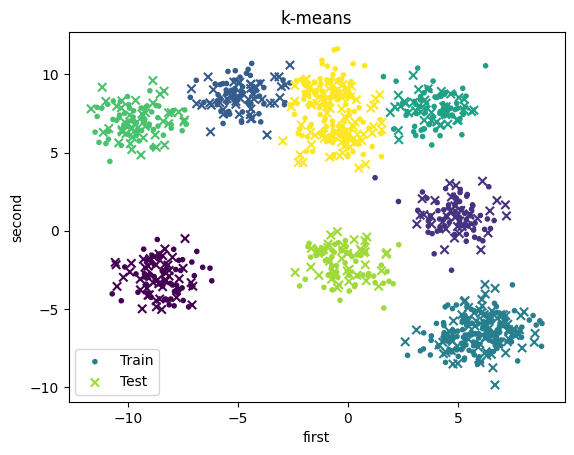

In [134]:
show_model_result(model1, train_labels1, CLUSTERS_COUNT)

Silhouette_score of [spectral clustering]: 0.597


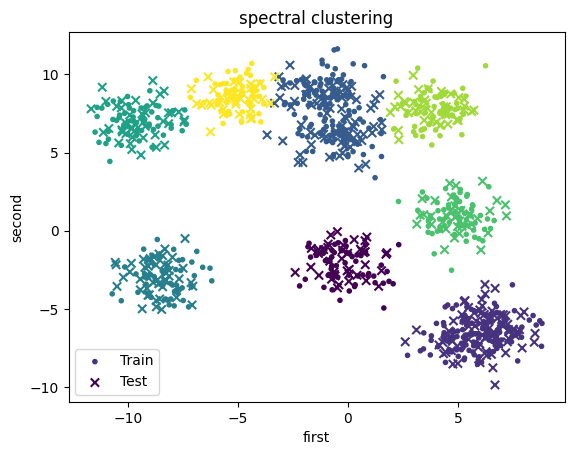

In [135]:
show_model_result(model2, train_labels2, CLUSTERS_COUNT)

Silhouette_score of [gaussian mixtures]: 0.599


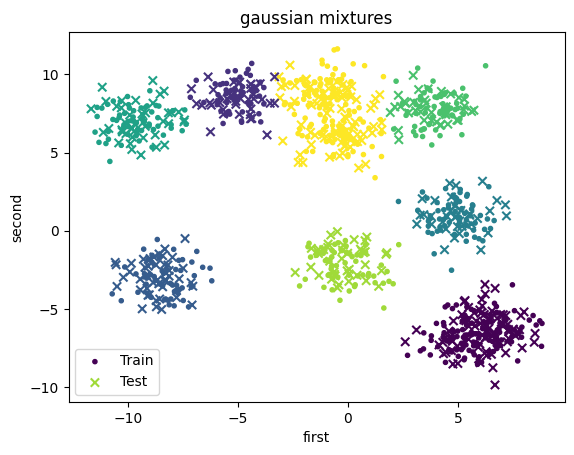

In [136]:
show_model_result(model3, train_labels3, CLUSTERS_COUNT)